# CMNIST generator-correction study

This notebook loads the completed online run and compares independent and OT correction at their validation-selected best and final checkpoints.

The run uses one fixed set of 20,000 independently generated observational rows (not paired colors), batch size 128, Gaussian base noise with standard deviation 0.1, 100,000 nuisance updates, and 200,000 updates for each target flow. The target plug-in reservoir is refreshed every 10,000 completed updates. Best checkpoints are selected on a fixed 512-sample-per-arm validation draw and compared with the final 200k checkpoints on a separate shared 5,000-sample-per-arm test draw.


In [1]:
from pathlib import Path
import json
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torchvision.utils import make_grid

_here = Path.cwd().resolve()
REPO_ROOT = next(p for p in [_here, *_here.parents] if (p / "src" / "deconfoundingfm").exists())
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from deconfoundingfm.experimental import (
    load_cmnist_correction_checkpoint,
    load_result_bundle,
)

RESULT_DIR = Path(os.environ.get(
    "CMNIST_RESULT_DIR",
    REPO_ROOT / "examples" / "cmnist" / "results" / "default",
)).resolve()
bundle = load_result_bundle(RESULT_DIR)
config = bundle["config"]
print("Result directory:", RESULT_DIR)
print("Evaluation samples per arm:", config["eval_n"])
print(
    "Study:", config["study_mode"],
    "| observations:", config["observational_n"], config["observational_design"],
    "| batch:", config["batch_size"],
    "| nuisance/target updates:", config["nuisance_steps"], config["target_steps"],
    "| base noise std:", config["base_noise_std"],
    "| reservoir refresh:", config["plugin_reservoir_update_frequency"],
)
print("Saved bundle keys:", sorted(bundle))


Result directory: /nfs/ghome/live/danceh/DeconfoundingFlowMatching/examples/cmnist/results/default
Evaluation samples per arm: 5000
Study: online_generator | observations: 20000 iid_observational | batch: 128 | nuisance/target updates: 100000 200000 | base noise std: 0.1 | reservoir refresh: 10000
Saved bundle keys: ['color_diagnostics', 'color_values', 'config', 'convergence', 'data_manifest', 'manifest', 'metrics', 'model_manifest', 'path', 'samples', 'trajectories', 'trajectory_summary']


## Final sliced-Wasserstein metrics

SW2 is computed separately for each treatment arm and then averaged. Every method uses the same random projection directions.


In [2]:
metrics = bundle["metrics"]
selection = metrics["checkpoint_selection"]
rows = [{"method": "Uncorrected source", "checkpoint": "--", "SW2": metrics["source_sw2"]}]
for method, label in (("decfm", "Independent"), ("ot", "OT")):
    rows.extend([
        {
            "method": f"{label} (validation-selected best)",
            "checkpoint": selection[method]["best_step"],
            "SW2": selection[method]["test_best_sw2"],
        },
        {
            "method": f"{label} (final)",
            "checkpoint": selection[method]["final_step"],
            "SW2": selection[method]["test_final_sw2"],
        },
    ])
display(pd.DataFrame(rows))
print(
    "Independent test n per arm:", metrics["evaluation_n_per_arm"],
    "| SW2 projections:", metrics["sw2_projections"],
)


,method,checkpoint,SW2
0,Uncorrected source,--,0.032547
1,Independent (validation-selected best),100000,0.012339
2,Independent (final),200000,0.013941
3,OT (validation-selected best),200000,0.008950
4,OT (final),200000,0.008950


Independent test n per arm: 5000 | SW2 projections: 256


## Generated samples

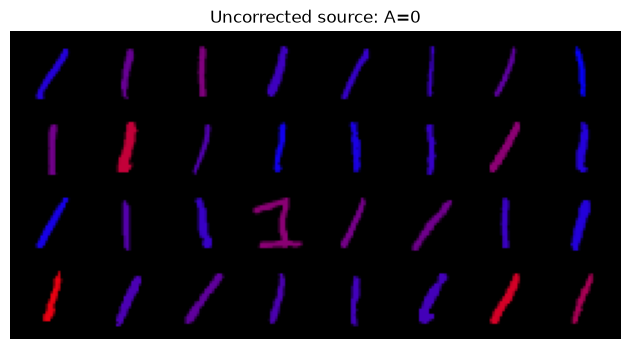

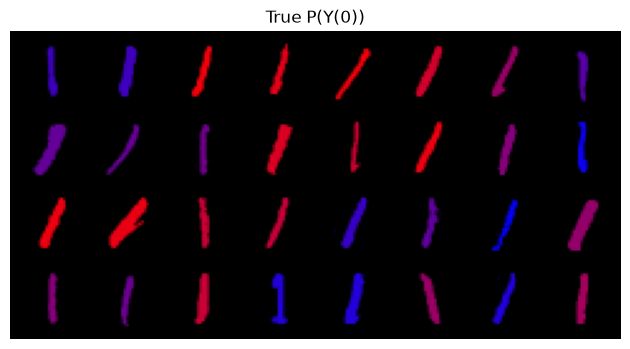

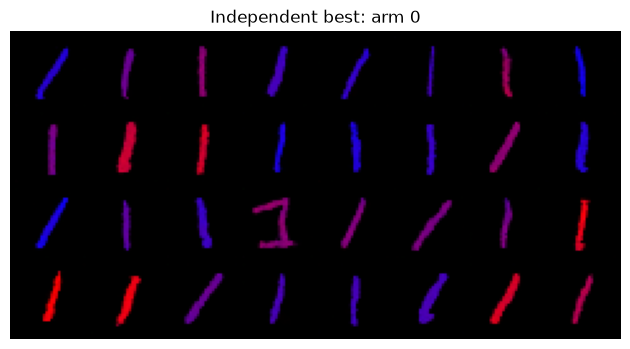

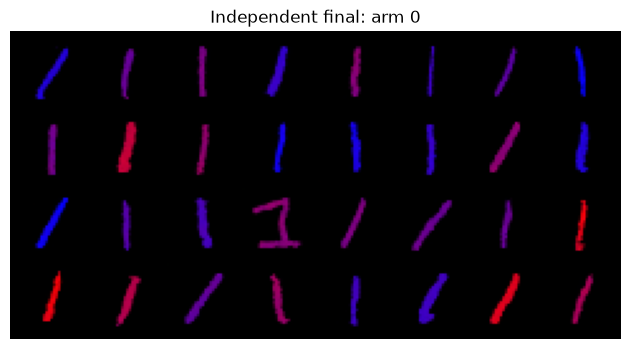

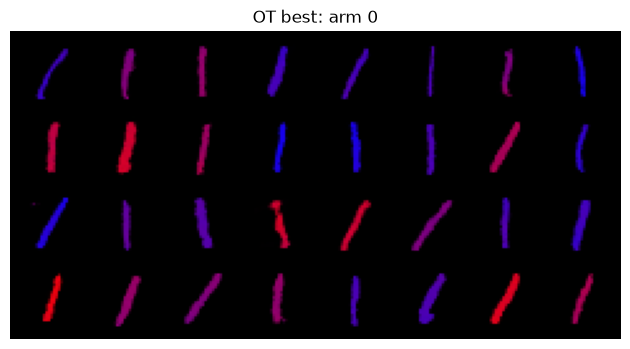

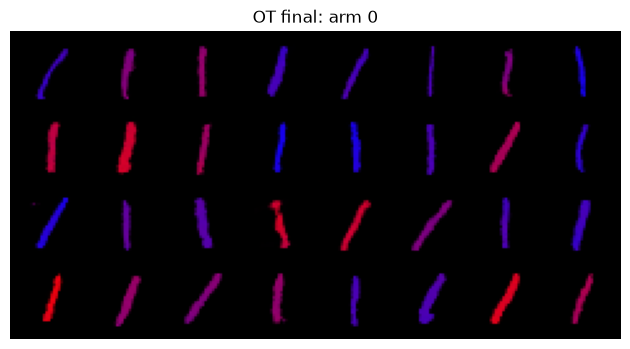

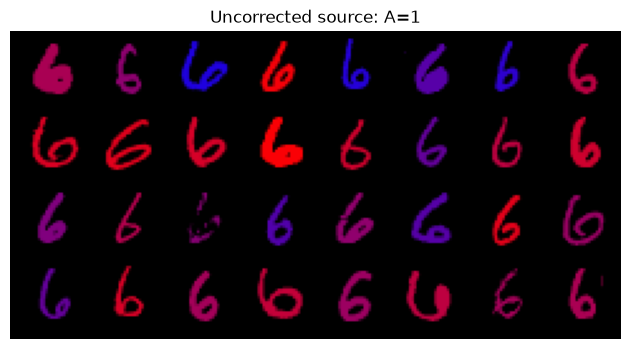

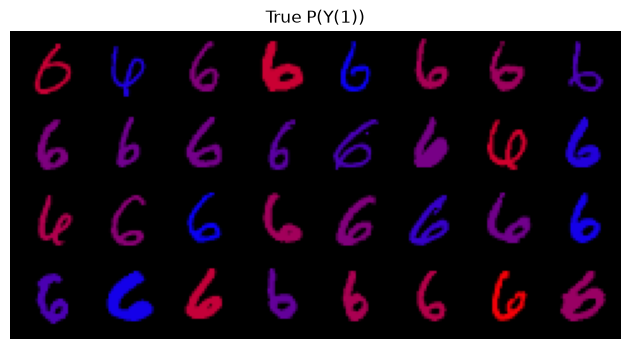

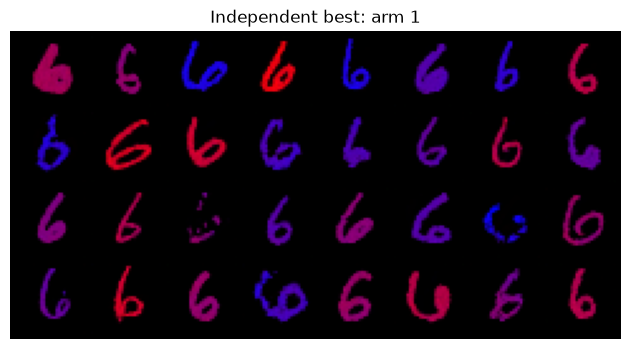

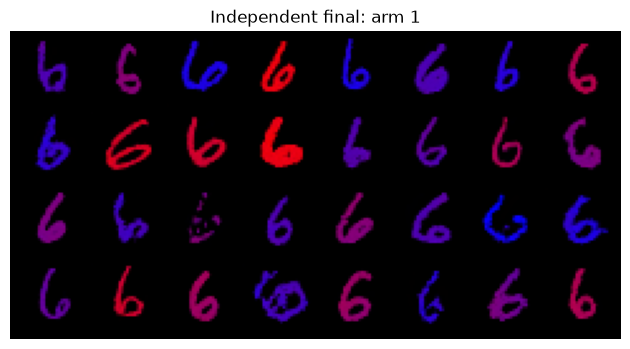

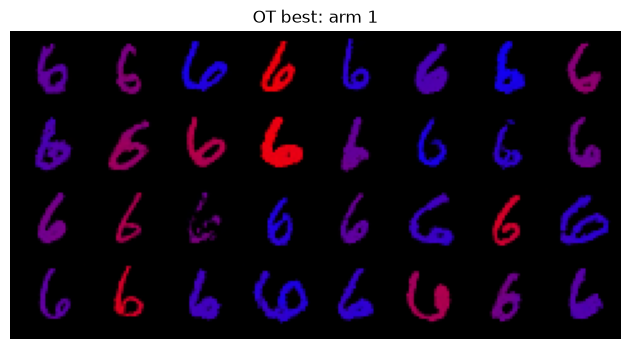

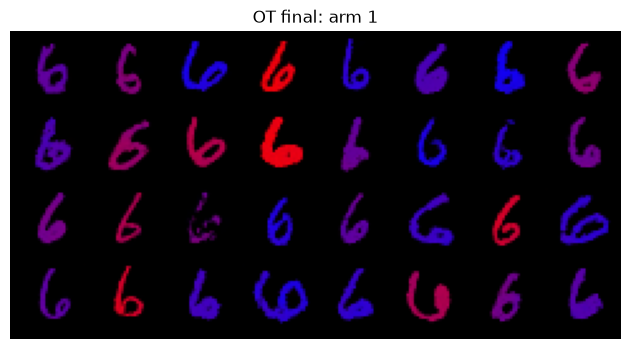

In [3]:
samples = bundle["samples"]

def show_grid(images, title, n=32, nrow=8):
    grid = make_grid(images[:n].clamp(0, 1), nrow=nrow).permute(1, 2, 0).cpu()
    plt.figure(figsize=(8, 4))
    plt.imshow(grid)
    plt.title(title)
    plt.axis("off")
    plt.show()

for key, title in (
    ("observed_a0", "Uncorrected source: A=0"),
    ("true_a0", "True P(Y(0))"),
    ("decfm_best_a0", "Independent best: arm 0"),
    ("decfm_a0", "Independent final: arm 0"),
    ("ot_best_a0", "OT best: arm 0"),
    ("ot_a0", "OT final: arm 0"),
    ("observed_a1", "Uncorrected source: A=1"),
    ("true_a1", "True P(Y(1))"),
    ("decfm_best_a1", "Independent best: arm 1"),
    ("decfm_a1", "Independent final: arm 1"),
    ("ot_best_a1", "OT best: arm 1"),
    ("ot_a1", "OT final: arm 1"),
):
    show_grid(samples[key], title)


## Validation SW2 and checkpoint selection

Every point uses the same deterministic 512-image truth set and the same noised base batch in each arm, with common projection directions. The starred minimum selects the stored best checkpoint for that method. Best and final are subsequently compared on a separate 5,000-per-arm test draw.


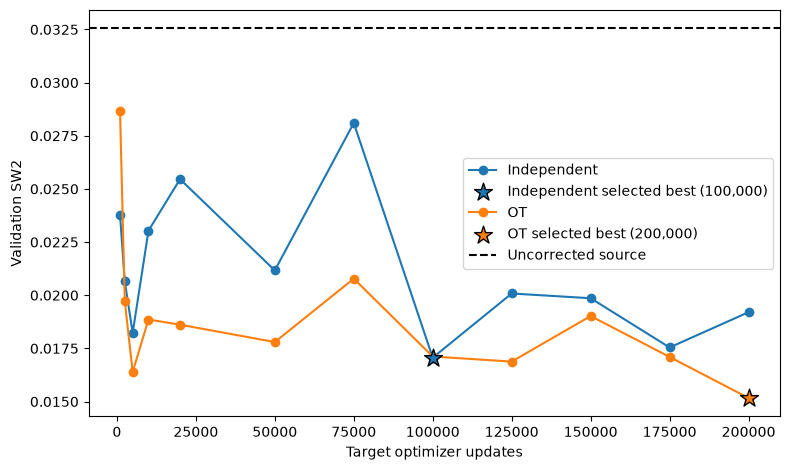

In [4]:
convergence = bundle["convergence"]
plt.figure(figsize=(8, 4.8))
colors = {"decfm": "tab:blue", "ot": "tab:orange"}
labels = {"decfm": "Independent", "ot": "OT"}
for method in ("decfm", "ot"):
    plt.plot(
        convergence["steps"],
        convergence[method],
        marker="o",
        color=colors[method],
        label=labels[method],
    )
    best_step = int(convergence["best_step_by_method"][method])
    best_index = convergence["steps"].index(best_step)
    plt.scatter(
        [best_step],
        [convergence[method][best_index]],
        marker="*",
        s=180,
        color=colors[method],
        edgecolor="black",
        zorder=5,
        label=f"{labels[method]} selected best ({best_step:,})",
    )
plt.axhline(metrics["source_sw2"], linestyle="--", color="black", label="Uncorrected source")
plt.xlabel("Target optimizer updates")
plt.ylabel("Validation SW2")
plt.legend()
plt.tight_layout()
plt.show()


## Learned color distributions \(P(X(a))\)

For each generated image, color is recovered as total foreground red mass divided by total foreground red-plus-blue mass, matching the paper's \(R/(R+B)\) transformation. The causal target is uniform for both arms.


In [5]:
color_diag = bundle["color_diagnostics"]
color_rows = [
    {"method": method, **values}
    for method, values in color_diag.items()
]
display(pd.DataFrame(color_rows))


,method,arm0_vs_arm1_w1,arm0_vs_uniform_w1,arm1_vs_uniform_w1,arm0_vs_uniform_ks,arm1_vs_uniform_ks,n_images_arm0,n_images_arm1
0,source,0.327649,0.164618,0.163030,0.261042,0.255161,5000,5000
1,truth,0.007604,0.002593,0.005952,0.009935,0.015862,5000,5000
2,decfm,0.075355,0.102875,0.034596,0.162965,0.059105,5000,5000
3,ot,0.032395,0.045121,0.030202,0.076584,0.058182,5000,5000
4,decfm_best,0.077776,0.079897,0.021713,0.126881,0.064275,5000,5000
5,ot_best,0.032395,0.045121,0.030202,0.076584,0.058182,5000,5000


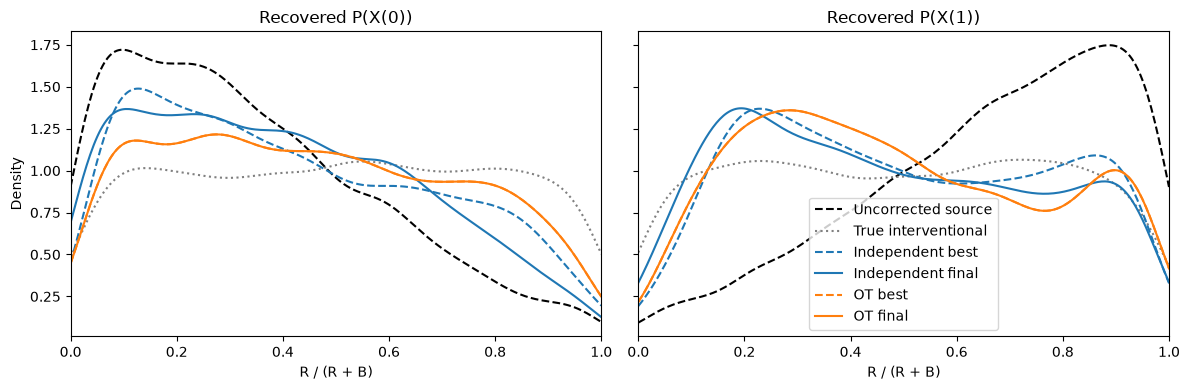

In [6]:
color_values = bundle["color_values"]

def kde(values, grid):
    values = values[torch.isfinite(values)].float()
    bandwidth = max(1.06 * float(values.std(unbiased=False)) * len(values) ** (-0.2), 0.015)
    z = (grid[:, None] - values[None, :]) / bandwidth
    density = torch.exp(-0.5 * z.square()).mean(dim=1) / (bandwidth * (2 * torch.pi) ** 0.5)
    return density

grid = torch.linspace(0, 1, 300)
styles = {
    "source": {"label": "Uncorrected source", "linestyle": "--", "color": "black"},
    "truth": {"label": "True interventional", "linestyle": ":", "color": "gray"},
    "decfm_best": {"label": "Independent best", "linestyle": "--", "color": "tab:blue"},
    "decfm": {"label": "Independent final", "linestyle": "-", "color": "tab:blue"},
    "ot_best": {"label": "OT best", "linestyle": "--", "color": "tab:orange"},
    "ot": {"label": "OT final", "linestyle": "-", "color": "tab:orange"},
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for arm, ax in enumerate(axes):
    for method, style in styles.items():
        values = color_values[method][f"arm{arm}"]
        ax.plot(grid, kde(values, grid), **style)
    ax.set_title(f"Recovered P(X({arm}))")
    ax.set_xlabel("R / (R + B)")
    ax.set_xlim(0, 1)
axes[0].set_ylabel("Density")
axes[1].legend()
plt.tight_layout()
plt.show()


## Flow-change and path diagnostics

The saved trajectory diagnostics use the final 200k correction states. A shared batch of 512 base images per arm receives Gaussian base noise and is transformed by both methods. Endpoint change is measured only over foreground pixels identified from the corresponding clean source digit, so background noise does not define the mask. Full trajectories are retained for the top- and bottom-changing examples.


In [7]:
trajectory_summary = bundle["trajectory_summary"]
rows = []
for method in ("decfm", "ot"):
    rows.append({"method": method, **trajectory_summary[method]["average_over_arms"]})
display(pd.DataFrame(rows))


,method,mean_foreground_pixel_change,mean_path_length,mean_endpoint_displacement,mean_straightness_ratio,mean_bar_E_v,mean_bar_E_vdot,dimension,n_trajectories_per_arm
0,decfm,0.118740,0.165146,0.119933,1.461520,0.028754,1.543325,2352,512
1,ot,0.131352,0.136650,0.120068,1.163505,0.019568,0.518897,2352,512


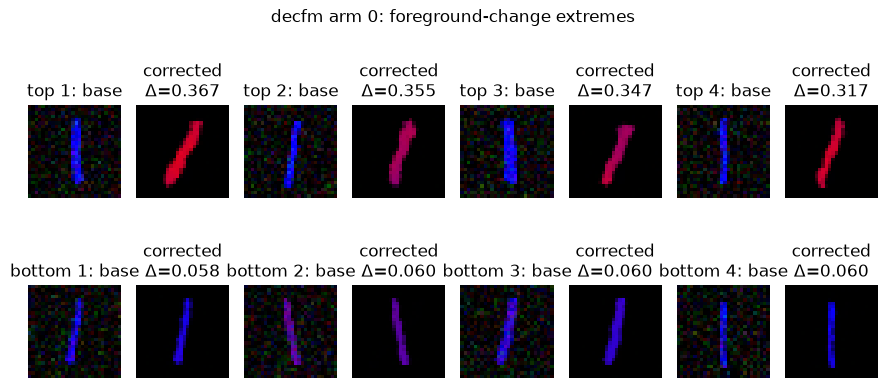

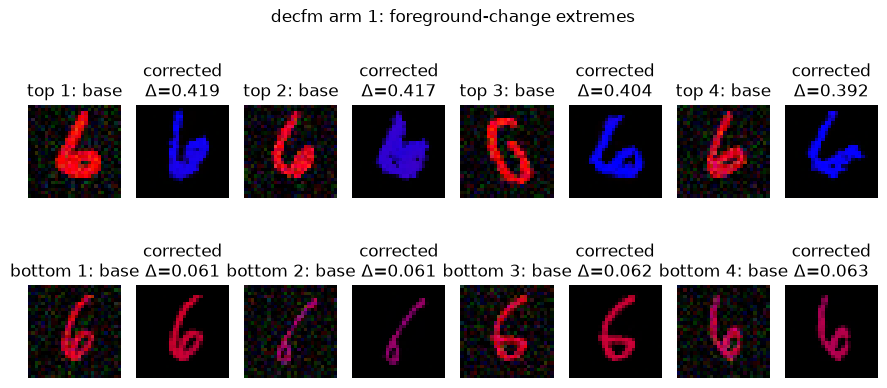

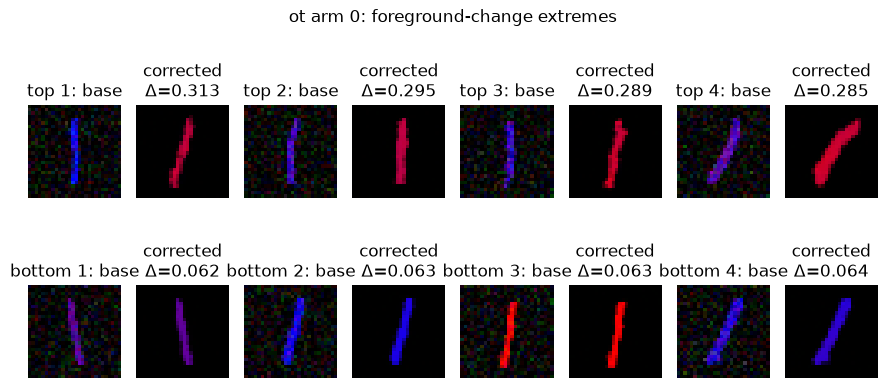

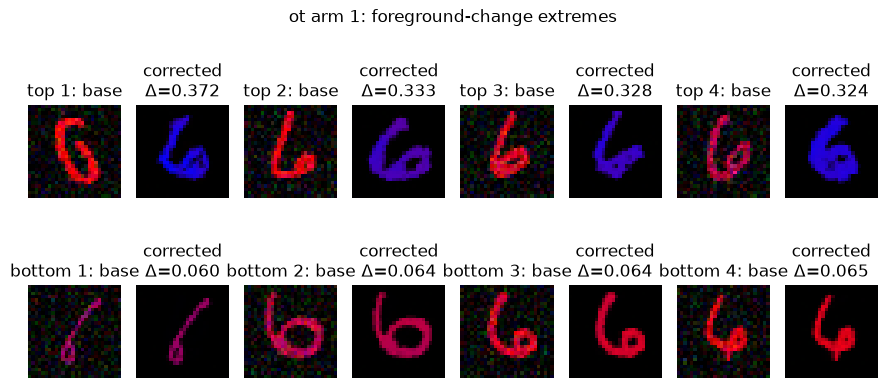

In [8]:
trajectories = bundle["trajectories"]

def show_change_extremes(method, arm, keep=4):
    record = trajectories[method][f"arm{arm}"]
    fig, axes = plt.subplots(2, 2 * keep, figsize=(2.2 * keep, 4.5))
    for row, extreme in enumerate(("top", "bottom")):
        selected = record[extreme]
        sequence = selected["trajectory"]
        scores = selected["foreground_pixel_change"]
        for j in range(min(keep, sequence.shape[1])):
            axes[row, 2*j].imshow(sequence[0, j].permute(1, 2, 0).clamp(0, 1))
            axes[row, 2*j].set_title(f"{extreme} {j+1}: base")
            axes[row, 2*j+1].imshow(sequence[-1, j].permute(1, 2, 0).clamp(0, 1))
            axes[row, 2*j+1].set_title(f"corrected\nΔ={scores[j]:.3f}")
        for ax in axes[row]:
            ax.axis("off")
    fig.suptitle(f"{method} arm {arm}: foreground-change extremes")
    plt.tight_layout()
    plt.show()

for method in ("decfm", "ot"):
    for arm in (0, 1):
        show_change_extremes(method, arm)


## Selected full trajectories

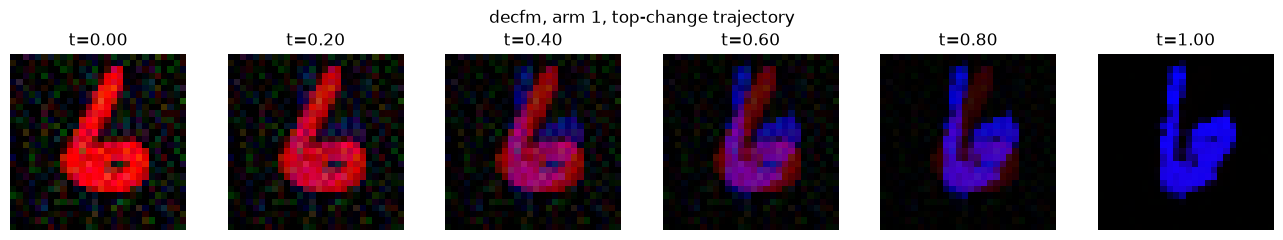

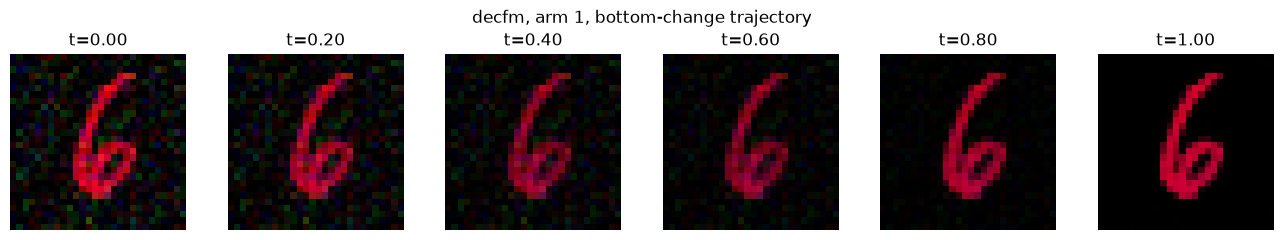

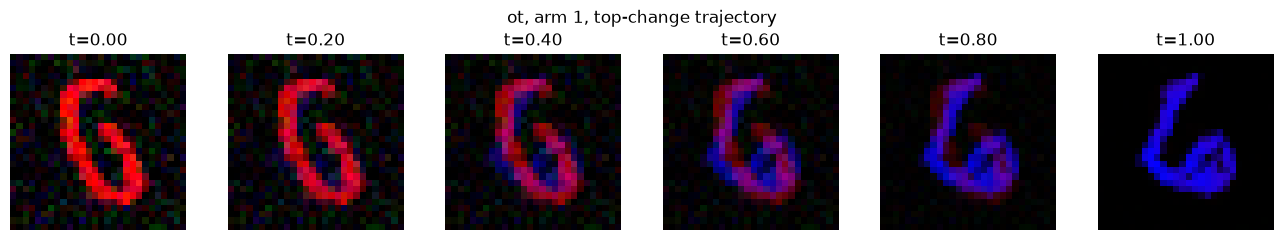

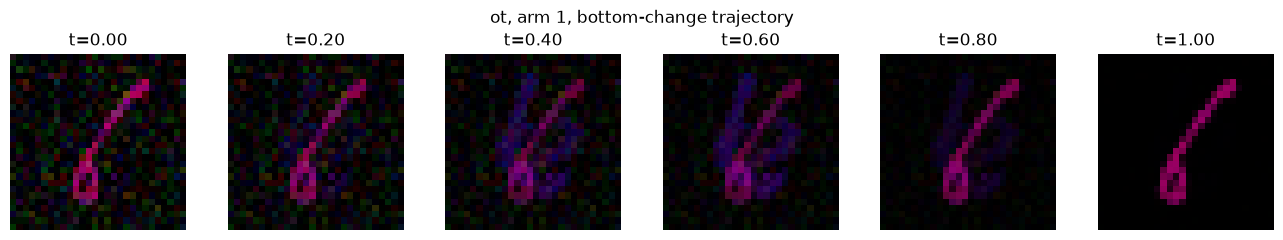

In [9]:
def show_saved_trajectory(method, arm, extreme="top", rank=0, frames=6):
    sequence = trajectories[method][f"arm{arm}"][extreme]["trajectory"][:, rank]
    indices = torch.linspace(0, len(sequence) - 1, frames).long()
    fig, axes = plt.subplots(1, frames, figsize=(2.2 * frames, 2.4))
    for ax, index in zip(axes, indices):
        ax.imshow(sequence[index].permute(1, 2, 0).clamp(0, 1))
        ax.set_title(f"t={index.item()/(len(sequence)-1):.2f}")
        ax.axis("off")
    fig.suptitle(f"{method}, arm {arm}, {extreme}-change trajectory")
    plt.tight_layout()
    plt.show()

for method in ("decfm", "ot"):
    show_saved_trajectory(method, arm=1, extreme="top")
    show_saved_trajectory(method, arm=1, extreme="bottom")


## Fresh inference from saved best and final checkpoints

This comparison reconstructs the configured base distribution once, then sends the same fresh base images through the validation-selected best and final correction velocities. The checkpoints contain no nuisance models, propensity fits, plug-in reservoirs, or cached base samples.


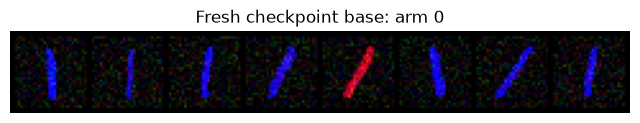

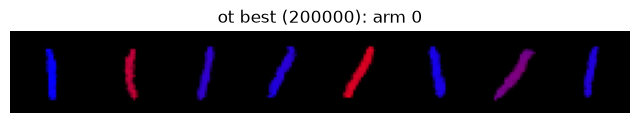

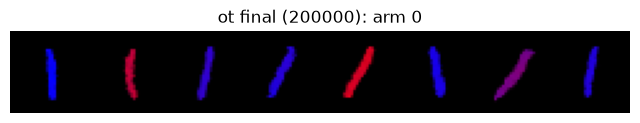

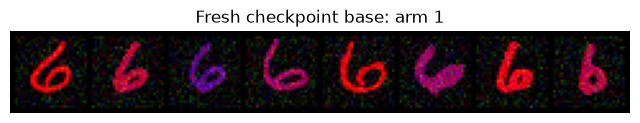

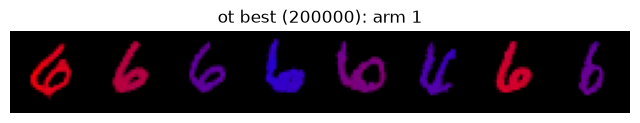

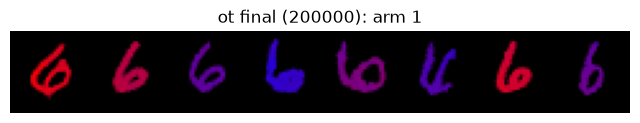

Best checkpoint: /nfs/ghome/live/danceh/DeconfoundingFlowMatching/examples/cmnist/results/default/models/ot/step_200000.pt
Final checkpoint: /nfs/ghome/live/danceh/DeconfoundingFlowMatching/examples/cmnist/results/default/models/ot/step_200000.pt
Inference device: cuda


In [10]:
model_manifest = bundle["model_manifest"]
INFERENCE_METHOD = "ot"
model_entry = model_manifest["models"][INFERENCE_METHOD]
BEST_STEP = str(model_entry["best_step"])
FINAL_STEP = str(model_entry["final_step"])
INFERENCE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

best_checkpoint_path = RESULT_DIR / model_entry["checkpoints"][BEST_STEP]
final_checkpoint_path = RESULT_DIR / model_entry["checkpoints"][FINAL_STEP]
best_sampler = load_cmnist_correction_checkpoint(best_checkpoint_path, device=INFERENCE_DEVICE)
final_sampler = load_cmnist_correction_checkpoint(final_checkpoint_path, device=INFERENCE_DEVICE)

torch.manual_seed(config["seed"] + 9000)
fresh = {}
for arm in (0, 1):
    y0 = final_sampler.sample_base(arm, 8)
    y_best = best_sampler.transform(arm, y0)
    y_final = final_sampler.transform(arm, y0)
    fresh[arm] = {
        "base": y0.cpu(),
        "best": y_best.cpu(),
        "final": y_final.cpu(),
    }
    show_grid(y0.cpu(), f"Fresh checkpoint base: arm {arm}", n=8)
    show_grid(y_best.cpu(), f"{INFERENCE_METHOD} best ({BEST_STEP}): arm {arm}", n=8)
    show_grid(y_final.cpu(), f"{INFERENCE_METHOD} final ({FINAL_STEP}): arm {arm}", n=8)

print("Best checkpoint:", best_checkpoint_path)
print("Final checkpoint:", final_checkpoint_path)
print("Inference device:", INFERENCE_DEVICE)


In [11]:
# New trajectories can be generated from either retained checkpoint.
fresh_trajectory, fresh_midpoint_velocities = final_sampler.trajectory(
    arm=1, y0=fresh[1]["base"][:2].to(INFERENCE_DEVICE)
)
print("final trajectory shape:", tuple(fresh_trajectory.shape))
print("final midpoint velocity shape:", tuple(fresh_midpoint_velocities.shape))


final trajectory shape: (51, 2, 3, 28, 28)
final midpoint velocity shape: (50, 2, 3, 28, 28)


## Reconstructing the observational population

The exact fixed population of 20,000 independently generated observational rows is reproducible from the packaged MNIST UByte files, saved DGP configuration, observational design, size, and seed. Set the flag below when the full tensors are needed for a post-hoc analysis.


In [12]:
RECREATE_OBSERVATIONAL_DATA = False
if RECREATE_OBSERVATIONAL_DATA:
    observational = sampler.recreate_observational_population(device="cpu")
    print({key: tuple(value.shape) for key, value in observational.items() if isinstance(value, torch.Tensor)})
else:
    print(json.dumps(bundle["data_manifest"], indent=2))


{
  "reconstruction": "ColorMNISTDGP(CMNISTConfig(**dgp_config)).make_iid_observational_population(observational_n, seed=observational_seed)",
  "observational_design": "iid_observational",
  "observational_seed": 0,
  "dgp_config": {
    "digits": [
      1,
      6
    ],
    "x_low": 0.0,
    "x_high": 1.0,
    "propensity_w": 5.0,
    "tau": 0.08,
    "k": 10.0,
    "fg_alpha": 0.0
  },
  "observational_n": 20000,
  "direct_observational_tensor_saved": false,
  "display_artifact_encoding": "uint8_rgb_scaled_by_255",
  "source_generator": "ExactColorMNISTSourceGenerator",
  "fresh_base_samples_available": true
}
